In [202]:
#Loading libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_theme()   # one consistent chart style for the whole notebook
import warnings
warnings.simplefilter('ignore')

In [203]:
# openpyxl reads the Excel file; folium draws the interactive map
%pip install openpyxl folium

DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621
DEPRECATION: Configuring installation scheme with distutils config files is deprecated and will no longer work in the near future. If you are using a Homebrew or Linuxbrew Python, please see discussion at https://github.com/Homebrew/homebrew-core/issues/76621

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python3.9 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [204]:
#loading the dataset
df=pd.read_excel('Group Project Data-SFD Data-Toronto Police.xlsx')
df.head()

,X,Y,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_DOY,OCC_DAY,OCC_HOUR,OCC_TIME_RANGE,DIVISION,DEATH,INJURIES,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84
0,-79.234955,43.781528,1,GO-2004397105,2004/05/15 04:00:00+00,2004,May,Saturday,136,15,1,Night,D41,0,0,142,Woburn North,137,Woburn (137),-79.234955,43.781528
1,-79.618218,43.733547,2,GO-2004600109,2004/07/26 04:00:00+00,2004,July,Monday,208,26,23,Evening,D23,0,0,1,West Humber-Clairville,1,West Humber-Clairville (1),-79.618218,43.733547
2,-79.518759,43.769157,3,GO-2004311851,2004/05/14 04:00:00+00,2004,May,Friday,135,14,16,Afternoon,D31,1,1,24,Black Creek,24,Black Creek (24),-79.518759,43.769157
3,-79.378870,43.660665,4,GO-2004736004,2004/12/19 05:00:00+00,2004,December,Sunday,354,19,0,Night,D51,1,0,168,Downtown Yonge East,75,Church-Yonge Corridor (75),-79.378870,43.660665
4,-79.212435,43.812075,5,GO-2004303455,2004/04/12 04:00:00+00,2004,April,Monday,103,12,22,Evening,D42,0,0,146,Malvern East,132,Malvern (132),-79.212435,43.812075


# Data Cleaning

First, we check whether there is any missing data in the dataset.

In [205]:
#Missing Percentage
missing_percent= df.isnull().sum()*100/len(df)
missing_values=pd.DataFrame({'missing_percent':missing_percent})
missing_values=missing_values.sort_values('missing_percent')
missing_values

,missing_percent
X,0.0
NEIGHBOURHOOD_140,0.0
HOOD_140,0.0
NEIGHBOURHOOD_158,0.0
HOOD_158,0.0
INJURIES,0.0
DEATH,0.0
DIVISION,0.0
OCC_TIME_RANGE,0.0
LONG_WGS84,0.0


The table shows no empty cells. However, a closer look shows that missing information is hidden as codes: 64 rows have the neighbourhood `NSA` (Not Specified Area), and 62 of them have placeholder coordinates (0, -85.49) that point to the Pacific Ocean instead of Toronto. Let's look at these rows and convert `NSA` into proper missing values.

In [206]:
df[df['NEIGHBOURHOOD_158'] == 'NSA'].head()

,X,Y,OBJECTID,EVENT_UNIQUE_ID,OCC_DATE,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_DOY,OCC_DAY,OCC_HOUR,OCC_TIME_RANGE,DIVISION,DEATH,INJURIES,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,LONG_WGS84,LAT_WGS84
9,-85.488744,0.0,10,GO-2004683174,2004/10/15 04:00:00+00,2004,October,Friday,289,15,14,Afternoon,D31,1,0,NSA,NSA,NSA,NSA,-85.488744,0.0
22,-85.488744,0.0,23,GO-2004591518,2004/09/03 04:00:00+00,2004,September,Friday,247,3,15,Afternoon,D51,0,1,NSA,NSA,NSA,NSA,-85.488744,0.0
27,-85.488744,0.0,28,GO-2004577384,2004/07/09 04:00:00+00,2004,July,Friday,191,9,10,Morning,D14,0,0,NSA,NSA,NSA,NSA,-85.488744,0.0
78,-85.488744,0.0,79,GO-2004120070,2004/01/03 05:00:00+00,2004,January,Saturday,3,3,1,Night,D54,0,0,NSA,NSA,NSA,NSA,-85.488744,0.0
112,-85.488744,0.0,113,GO-2004692390,2004/10/23 04:00:00+00,2004,October,Saturday,297,23,2,Night,D14,0,1,NSA,NSA,NSA,NSA,-85.488744,0.0


In [207]:
df=df.replace(['NSA'], np.nan)
missing_percent=(df.isnull().sum()*100/len(df)).round(2)
missing_values=pd.DataFrame({'missing_percent': missing_percent})
missing_values = missing_values.sort_values('missing_percent')
missing_values

,missing_percent
X,0.00
INJURIES,0.00
DEATH,0.00
DIVISION,0.00
OCC_TIME_RANGE,0.00
LONG_WGS84,0.00
OCC_DAY,0.00
OCC_DOY,0.00
OCC_HOUR,0.00
OCC_MONTH,0.00


Now the neighbourhood columns show missing values. We remove the rows where the neighbourhood we use (`NEIGHBOURHOOD_158`) is unknown, because they can't be placed on the map or assigned to a neighbourhood. This removes 64 rows, about 1% of the data.

In [208]:
df=df.dropna(subset=['NEIGHBOURHOOD_158'])
missing_percent=(df.isnull().sum()*100/len(df)).round(2)
missing_values=pd.DataFrame({'missing_percent': missing_percent})
missing_values = missing_values.sort_values('missing_percent')
missing_values

,missing_percent
X,0.00
NEIGHBOURHOOD_158,0.00
HOOD_158,0.00
INJURIES,0.00
DEATH,0.00
DIVISION,0.00
OCC_TIME_RANGE,0.00
LONG_WGS84,0.00
OCC_DAY,0.00
OCC_HOUR,0.00


Two rows still have missing values, but only in the old 140-neighbourhood columns (`HOOD_140` and `NEIGHBOURHOOD_140`). Their current neighbourhood and location are known, so we keep them. Those columns are dropped in the next step.

The column names are hard to understand, so we will rename them. Before that, we drop the columns we don't need:

- `X` and `Y` are identical to `LONG_WGS84` and `LAT_WGS84`.
- `OBJECTID` and `EVENT_UNIQUE_ID` are record identifiers, and `OCC_DOY` (day of the year) repeats information we already have.
- `OCC_DATE` is also covered by the separate year, month, day, weekday and hour columns. Before dropping it, we extract its calendar date into a new `Date` column, which we need later to count incidents per month.
- `HOOD_158`, `HOOD_140` and `NEIGHBOURHOOD_140`: we use the City's current 158-neighbourhood boundaries (`NEIGHBOURHOOD_158`). The old 140-neighbourhood columns are not duplicates (they differ for about 23% of rows), but we only need one scheme.

In [209]:
# OCC_DATE holds midnight Toronto time stored in UTC, so convert it and keep only the calendar date.
# The Date column is needed later to count incidents per month.
df['Date'] = (pd.to_datetime(df['OCC_DATE'])
                .dt.tz_convert('America/Toronto')
                .dt.tz_localize(None)
                .dt.normalize())

#drop or removing unnecessary columns
df=df.drop(['X', 'Y', 'OCC_DATE','OBJECTID', 'EVENT_UNIQUE_ID', 'OCC_DOY', 'HOOD_158', 'HOOD_140','NEIGHBOURHOOD_140' ], axis=1)
df.head()

,OCC_YEAR,OCC_MONTH,OCC_DOW,OCC_DAY,OCC_HOUR,OCC_TIME_RANGE,DIVISION,DEATH,INJURIES,NEIGHBOURHOOD_158,LONG_WGS84,LAT_WGS84,Date
0,2004,May,Saturday,15,1,Night,D41,0,0,Woburn North,-79.234955,43.781528,2004-05-15
1,2004,July,Monday,26,23,Evening,D23,0,0,West Humber-Clairville,-79.618218,43.733547,2004-07-26
2,2004,May,Friday,14,16,Afternoon,D31,1,1,Black Creek,-79.518759,43.769157,2004-05-14
3,2004,December,Sunday,19,0,Night,D51,1,0,Downtown Yonge East,-79.378870,43.660665,2004-12-19
4,2004,April,Monday,12,22,Evening,D42,0,0,Malvern East,-79.212435,43.812075,2004-04-12


In [210]:
#renaming columns
df=df.rename(columns={
    'OCC_YEAR': 'Year',
    'OCC_MONTH': 'Month',
    'OCC_DOW': 'Weekdays',
    'OCC_DAY': 'Day_of_the_month',
    'OCC_HOUR': 'Hour',
    'OCC_TIME_RANGE': 'Time',
    'DIVISION': 'Division',
    'DEATH': 'Number_of_Death',
    'INJURIES': 'Number_of_Injuries',
    'NEIGHBOURHOOD_158': 'Neighbourhood',
    'LONG_WGS84': 'Longitude',
    'LAT_WGS84': 'Latitude'
    
})
df.head()

,Year,Month,Weekdays,Day_of_the_month,Hour,Time,Division,Number_of_Death,Number_of_Injuries,Neighbourhood,Longitude,Latitude,Date
0,2004,May,Saturday,15,1,Night,D41,0,0,Woburn North,-79.234955,43.781528,2004-05-15
1,2004,July,Monday,26,23,Evening,D23,0,0,West Humber-Clairville,-79.618218,43.733547,2004-07-26
2,2004,May,Friday,14,16,Afternoon,D31,1,1,Black Creek,-79.518759,43.769157,2004-05-14
3,2004,December,Sunday,19,0,Night,D51,1,0,Downtown Yonge East,-79.378870,43.660665,2004-12-19
4,2004,April,Monday,12,22,Evening,D42,0,0,Malvern East,-79.212435,43.812075,2004-04-12


Before starting the analysis, let's check whether there are any duplicate rows.

In [211]:
print('Number of duplicate rows:', df.duplicated().sum())

Number of duplicate rows: 8


There are 8 duplicated rows. Let's find out which rows they are.

In [212]:
df[df.duplicated(keep=False)]

,Year,Month,Weekdays,Day_of_the_month,Hour,Time,Division,Number_of_Death,Number_of_Injuries,Neighbourhood,Longitude,Latitude,Date
61,2004,April,Monday,5,20,Evening,D42,0,0,East L'Amoreaux,-79.305155,43.797109,2004-04-05
130,2004,April,Monday,5,20,Evening,D42,0,0,East L'Amoreaux,-79.305155,43.797109,2004-04-05
522,2006,February,Monday,6,13,Afternoon,D42,0,0,Malvern East,-79.211554,43.805534,2006-02-06
590,2006,February,Monday,6,13,Afternoon,D42,0,0,Malvern East,-79.211554,43.805534,2006-02-06
778,2007,August,Saturday,4,6,Morning,D51,0,1,Regent Park,-79.362998,43.660081,2007-08-04
869,2007,August,Saturday,4,6,Morning,D51,0,1,Regent Park,-79.362998,43.660081,2007-08-04
1136,2009,September,Wednesday,23,1,Night,D23,0,1,Kingsview Village-The Westway,-79.541389,43.696803,2009-09-23
1176,2009,September,Wednesday,23,1,Night,D23,0,1,Kingsview Village-The Westway,-79.541389,43.696803,2009-09-23
1698,2011,July,Monday,18,14,Afternoon,D31,0,0,Black Creek,-79.509777,43.760454,2011-07-18
1831,2011,July,Monday,18,14,Afternoon,D31,0,0,Black Creek,-79.509777,43.760454,2011-07-18


These pairs are identical in every column: the same date, hour, location, division, time of day, deaths and injuries. In the original data they have different `EVENT_UNIQUE_ID`s, so each pair could be two reports of the same shooting or two separate shootings at the same place and hour. Because every recorded detail is identical, we treat each pair as one incident recorded twice and remove the extra copy. Only 8 rows (about 0.1% of the data) are affected, so this choice has almost no effect on the results.

In [213]:
df=df.drop_duplicates()
print('Duplicate rows remaining:', df.duplicated().sum())
print('Incidents in the cleaned dataset:', len(df))

Duplicate rows remaining: 0
Incidents in the cleaned dataset: 5635


# Exploratory Data Analysis

Our dataset is now ready for exploratory analysis. The dataset records **shootings and firearm discharges**, so throughout this section we count *incidents* rather than all crimes. These are counts, not rates, because we don't adjust for population.

## Where do shootings happen?

First, let's look at the number of incidents in each neighbourhood.

In [214]:
df_neighbourhood=(df['Neighbourhood'].value_counts()
                    .rename_axis('Neighbourhood')
                    .reset_index(name='Incidents'))
print('Number of neighbourhoods:', len(df_neighbourhood))
df_neighbourhood.head()

Number of neighbourhoods: 158


,Neighbourhood,Incidents
0,Glenfield-Jane Heights,311
1,Black Creek,202
2,Mount Olive-Silverstone-Jamestown,192
3,West Humber-Clairville,132
4,York University Heights,117


With 158 neighbourhoods, a chart of all of them would be unreadable. Let's look at the 20 neighbourhoods with the most incidents.

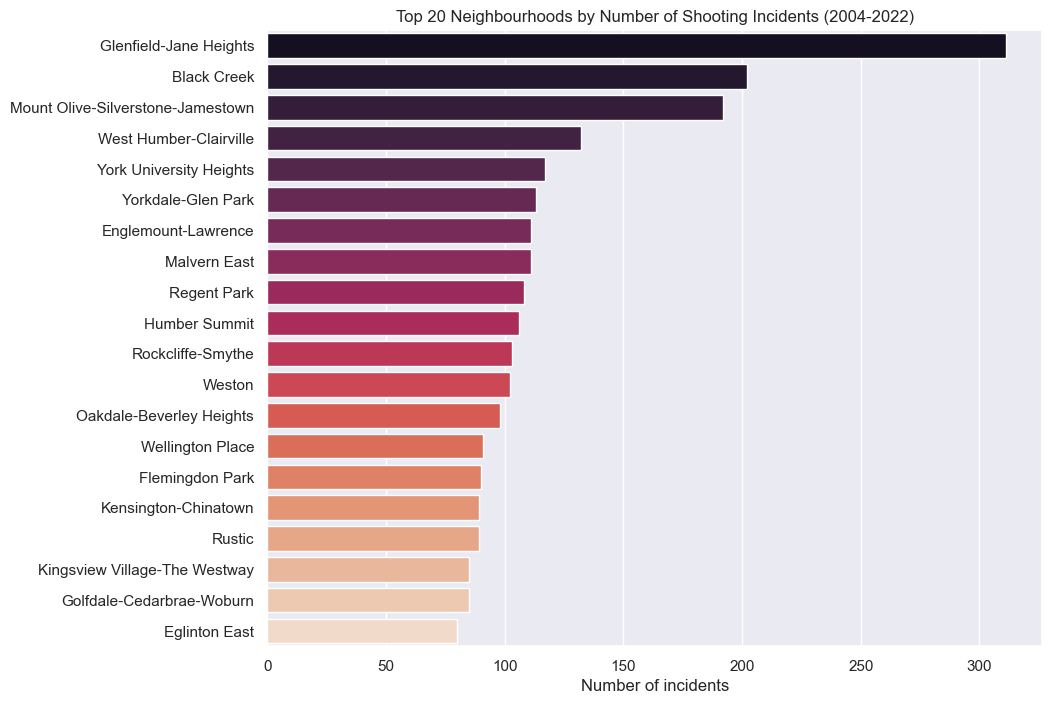

In [215]:
df_neighbourhood_top=df_neighbourhood.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x='Incidents', y='Neighbourhood', data=df_neighbourhood_top, palette='rocket')
plt.title('Top 20 Neighbourhoods by Number of Shooting Incidents (2004-2022)')
plt.xlabel('Number of incidents')
plt.ylabel('')
plt.savefig('top20_neighbourhoods.png', bbox_inches='tight')
plt.show()

**What this chart shows:** Shootings are heavily concentrated in a small number of neighbourhoods. Glenfield-Jane Heights has the most incidents by a wide margin (311), followed by Black Creek (202) and Mount Olive-Silverstone-Jamestown (192). These three neighbourhoods alone account for 12.5% of all 5,635 incidents, and the top 20 (about 13% of Toronto's 158 neighbourhoods) account for 42.9%.

Most of the top neighbourhoods are in the north-west of the city (the Jane-Finch area and north Etobicoke). A few downtown neighbourhoods also appear, such as Regent Park, Wellington Place and Kensington-Chinatown.

Next, let's see how the number of incidents changed from 2010 to 2022 in the three neighbourhoods with the most shootings.

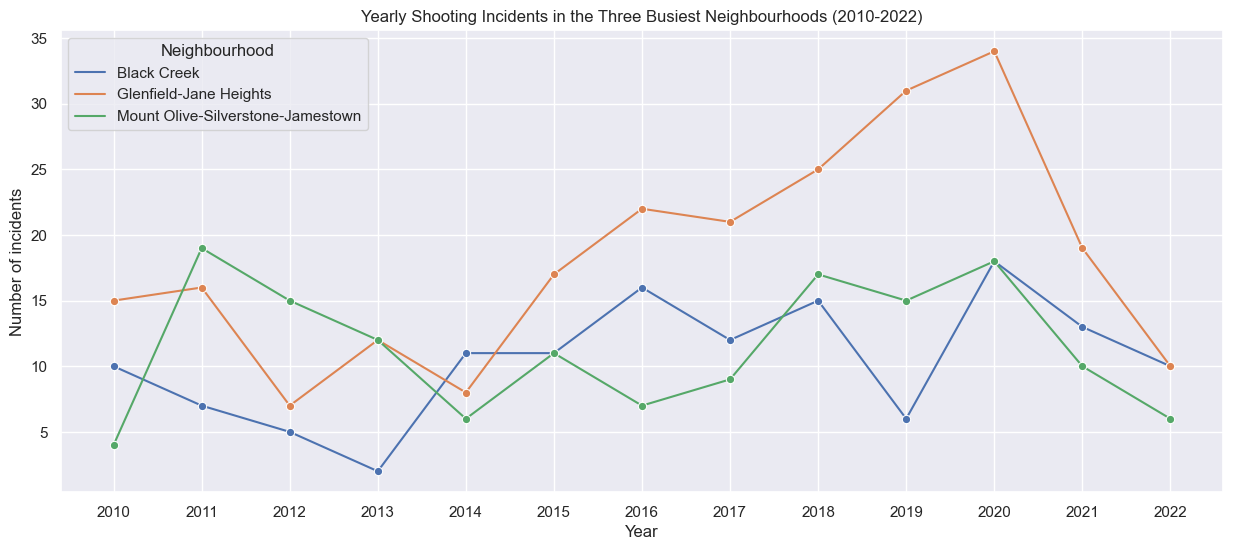

In [216]:
top3=df_neighbourhood['Neighbourhood'].head(3)
recent_top3=df[df['Neighbourhood'].isin(top3) & (df['Year']>=2010)]
# crosstab + stack keeps years with zero incidents in the table
df_neighbourhood_year=(pd.crosstab(recent_top3['Year'], recent_top3['Neighbourhood'])
                         .stack()
                         .reset_index(name='Incidents'))

plt.figure(figsize=(15, 6))
sns.lineplot(x='Year', y='Incidents', hue='Neighbourhood', data=df_neighbourhood_year, marker='o')
plt.title('Yearly Shooting Incidents in the Three Busiest Neighbourhoods (2010-2022)')
plt.xlabel('Year')
plt.ylabel('Number of incidents')
plt.xticks(range(2010, 2023))
plt.savefig('top3_neighbourhoods_by_year.png', bbox_inches='tight')
plt.show()

**What this chart shows:** The yearly incident counts for the three neighbourhoods with the most shootings, from 2010 to 2022.

- **Glenfield-Jane Heights** shows the clearest pattern: incidents rose from 7 in 2012 to a peak of 34 in 2020, then fell sharply to 10 in 2022.
- **Black Creek** and **Mount Olive-Silverstone-Jamestown** go up and down between 2 and 19 incidents a year, with no steady trend.
- All three neighbourhoods had fewer incidents in 2021 and 2022 than in 2020.

Because the yearly numbers per neighbourhood are small, a change of a few incidents looks like a big jump on the chart.

## When do shootings happen?

Next, we look at when shootings happen: by year, by month, by day of the week and by time of day.

In [217]:
df_year=df.groupby('Year').size().reset_index(name='Incidents')
df_year

,Year,Incidents
0,2004,182
1,2005,251
2,2006,207
3,2007,201
4,2008,235
5,2009,246
6,2010,251
7,2011,222
8,2012,214
9,2013,193


The table shows the number of incidents in each year from 2004 to 2022. A chart makes the trend easier to see.

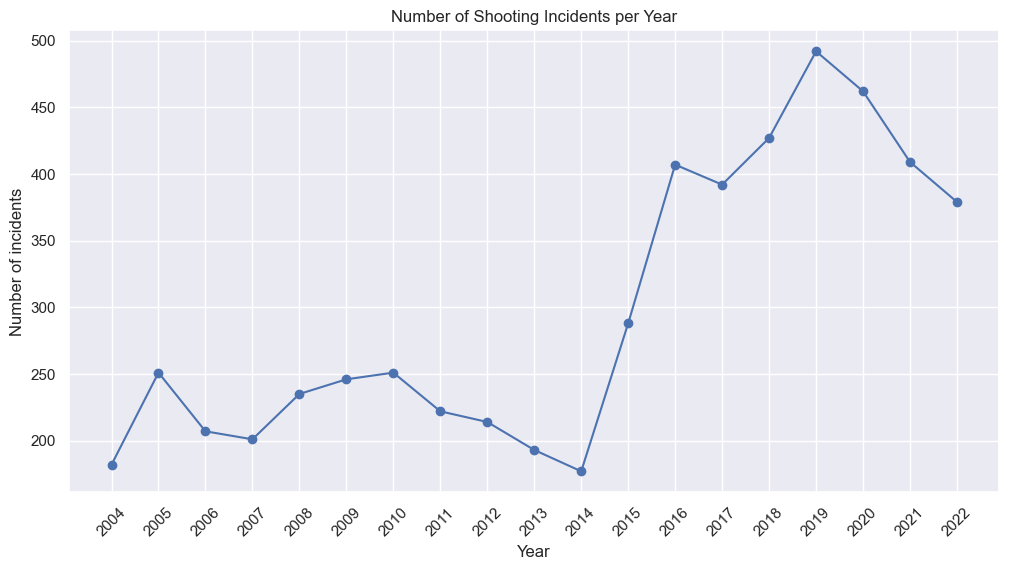

In [218]:
plt.figure(figsize=(12, 6))
plt.plot(df_year['Year'], df_year['Incidents'], marker='o')
plt.title('Number of Shooting Incidents per Year')
plt.xlabel('Year')
plt.ylabel('Number of incidents')
plt.xticks(df_year['Year'], rotation=45)
plt.savefig('incidents_per_year.png', bbox_inches='tight')
plt.show()

**What this chart shows:** Shootings in Toronto have not changed at a steady rate over time. There are three clear periods:

1. **2004–2014:** incidents stayed between about 180 and 250 a year, reaching a low of 177 in 2014.
2. **2015–2019:** incidents rose sharply, from 288 in 2015 to a peak of 492 in 2019, almost three times the 2014 level.
3. **2020–2022:** incidents declined each year, to 379 in 2022, but remained well above the pre-2015 level.

This change in trend matters for forecasting: a model trained mostly on the rising 2015–2019 period may predict that the increase continues.

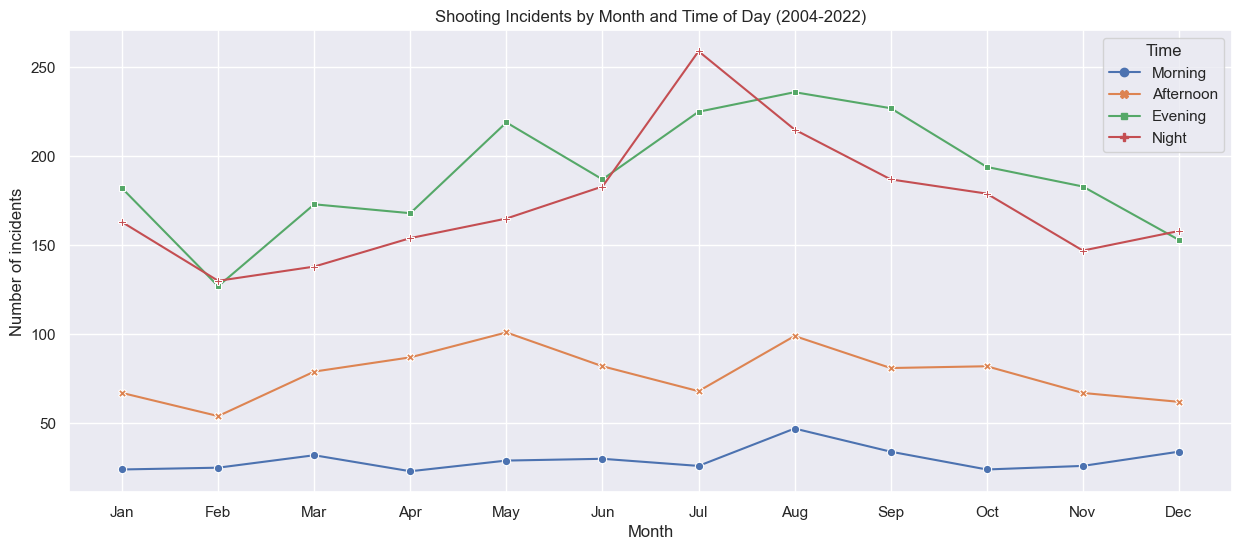

In [219]:
months=['January', 'February', 'March', 'April', 'May', 'June', 'July',
        'August', 'September', 'October', 'November', 'December']
time_order=['Morning', 'Afternoon', 'Evening', 'Night']

df_month=df.groupby(['Month', 'Time']).size().reset_index(name='Incidents')
df_month['Month_Num']=df_month['Month'].map({m: i for i, m in enumerate(months, start=1)})

plt.figure(figsize=(15, 6))
sns.lineplot(x='Month_Num', y='Incidents', hue='Time', style='Time', hue_order=time_order,
             style_order=time_order, markers=True, dashes=False, data=df_month)
plt.title('Shooting Incidents by Month and Time of Day (2004-2022)')
plt.xlabel('Month')
plt.ylabel('Number of incidents')
plt.xticks(range(1, 13), [m[:3] for m in months])
plt.savefig('incidents_by_month.png', bbox_inches='tight')
plt.show()

**What this chart shows:** The number of incidents in each month, split by time of day, for all years combined.

- **Summer has the most shootings.** August (597) and July (578) are the highest months, and February (336) is the lowest. February partly looks low because it has fewer days, but it is still the lowest month when measured per day.
- **Evening and night dominate every month.** Across the whole dataset, 40% of incidents happen in the evening and 37% at night, compared with 17% in the afternoon and only 6% in the morning.
- The summer increase is largest at night. July has the highest night-time count of any month (259).

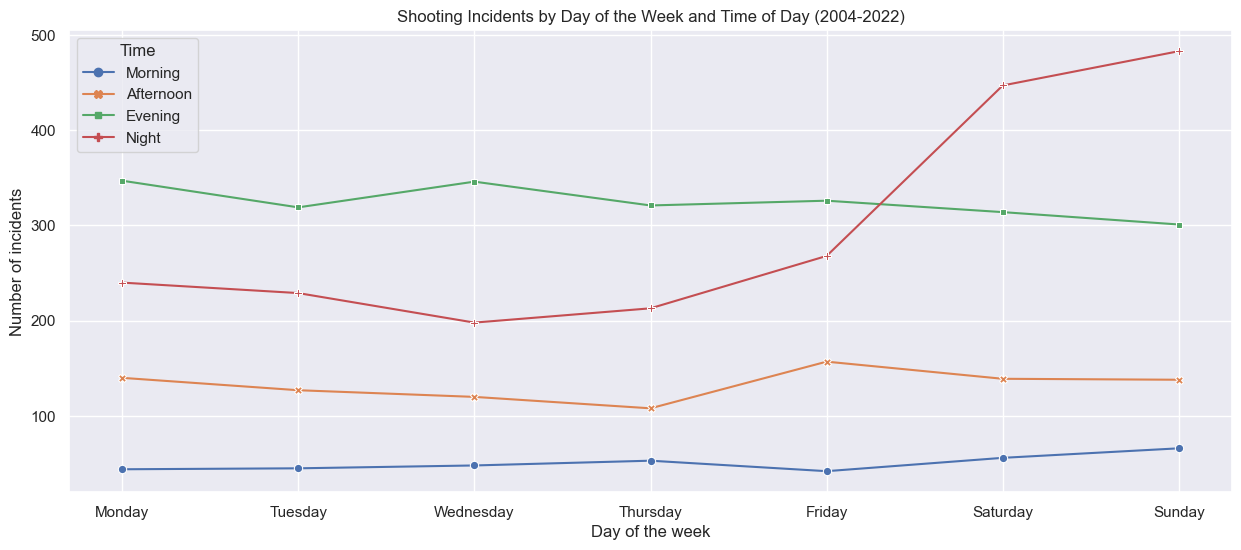

In [220]:
days=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df_days=df.groupby(['Weekdays', 'Time']).size().reset_index(name='Incidents')
df_days['Weekday_Num']=df_days['Weekdays'].map({d: i for i, d in enumerate(days, start=1)})

plt.figure(figsize=(15, 6))
sns.lineplot(x='Weekday_Num', y='Incidents', hue='Time', style='Time', hue_order=time_order,
             style_order=time_order, markers=True, dashes=False, data=df_days)
plt.title('Shooting Incidents by Day of the Week and Time of Day (2004-2022)')
plt.xlabel('Day of the week')
plt.ylabel('Number of incidents')
plt.xticks(range(1, 8), days)
plt.savefig('incidents_by_weekday.png', bbox_inches='tight')
plt.show()

**What this chart shows:** The number of incidents on each day of the week, split by time of day.

- **Weekends have the most shootings:** Sunday (988) and Saturday (956), compared with 695 on Thursday, the quietest day.
- **The weekend increase comes almost entirely from night-time incidents.** Night incidents on Sunday (483) and Saturday (447) are more than double those on Wednesday (198). Since "night" covers midnight to 5:59 AM, Sunday night incidents are mostly the late hours of Saturday night.
- **Evening incidents are stable across the week** (about 300–350 per day), so the weekday/weekend difference is a night-time pattern.

In [221]:
import folium
from folium import plugins

# Centre the map on Toronto and group nearby incidents into clusters
toronto_map=folium.Map(location=[43.651070, -79.347015], zoom_start=11)
incidents=plugins.MarkerCluster().add_to(toronto_map)

for lat, lng, label in zip(df['Latitude'], df['Longitude'], df['Neighbourhood']):
    folium.Marker(location=[lat, lng], popup=label).add_to(incidents)

# Save the map as a separate file instead of showing it here (it would add about 5 MB to the notebook)
toronto_map.save('toronto_map.html')
print('Map saved to toronto_map.html')

Map saved to toronto_map.html


**What this map shows:** Each marker is one incident. Nearby markers are grouped into clusters that show how many incidents are in that area, and zooming in splits them into smaller clusters.

The map confirms the neighbourhood chart: the largest clusters are in the north-west (Jane-Finch and north Etobicoke). There are smaller hotspots downtown and in north-east Scarborough (e.g. Malvern East). Rows with an unknown location (NSA) were removed during cleaning, so every marker is in Toronto.

The interactive map is saved as `toronto_map.html` and can be opened in a web browser.

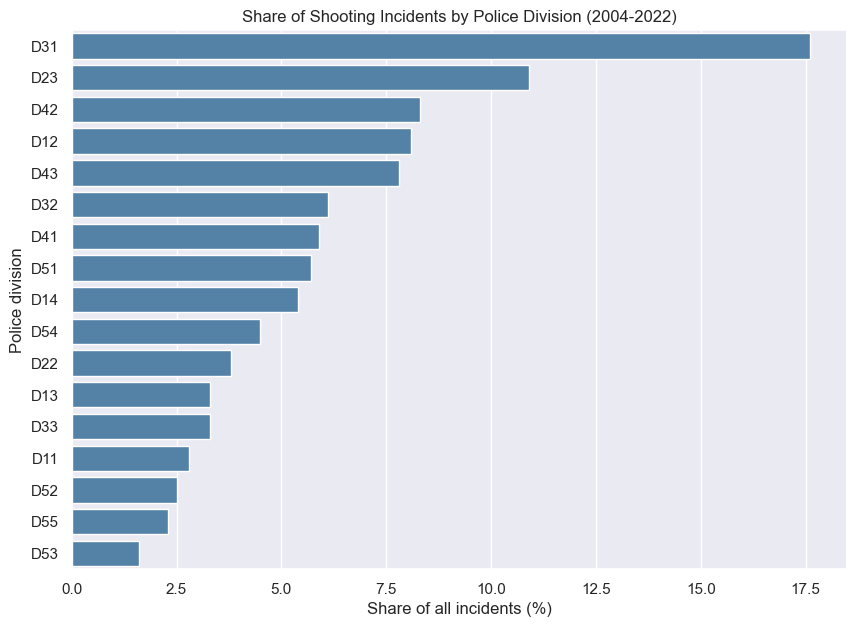

,Division,Incidents,Share_%
0,D31,991,17.6
1,D23,613,10.9
2,D42,469,8.3
3,D12,457,8.1
4,D43,441,7.8
5,D32,341,6.1
6,D41,332,5.9
7,D51,323,5.7
8,D14,307,5.4
9,D54,255,4.5


In [222]:
# Share of incidents in each police division, from largest to smallest
division=(df['Division'].value_counts()
            .rename_axis('Division')
            .reset_index(name='Incidents'))
division['Share_%']=(division['Incidents']/division['Incidents'].sum()*100).round(1)

plt.figure(figsize=(10, 7))
sns.barplot(x='Share_%', y='Division', data=division, color='steelblue')
plt.title('Share of Shooting Incidents by Police Division (2004-2022)')
plt.xlabel('Share of all incidents (%)')
plt.ylabel('Police division')
plt.savefig('incidents_by_division.png', bbox_inches='tight')
plt.show()
division

**What this chart shows:** Each police division's share of all shooting incidents.

- **Division 31 (D31)** has by far the largest share at 17.6%, almost one in every five incidents. It covers the north-west of the city, including the Jane-Finch area, which matches the neighbourhood results above.
- **D23** (10.9%), **D42** (8.3%), **D12** (8.1%) and **D43** (7.8%) follow. Together, the top 5 of the 17 divisions account for more than half (52.7%) of all incidents.
- **D53** has the smallest share (1.6%).

In [223]:
df_death=df[['Year', 'Number_of_Death', 'Number_of_Injuries']]
df_death.head()

,Year,Number_of_Death,Number_of_Injuries
0,2004,0,0
1,2004,0,0
2,2004,1,1
3,2004,1,0
4,2004,0,0


In [224]:
# Double brackets select several columns (required in pandas 2)
df_death_year=df_death.groupby(['Year'])[['Number_of_Death', 'Number_of_Injuries']].sum().reset_index()
df_death_year.head()

,Year,Number_of_Death,Number_of_Injuries
0,2004,24,92
1,2005,51,171
2,2006,29,167
3,2007,44,125
4,2008,37,168


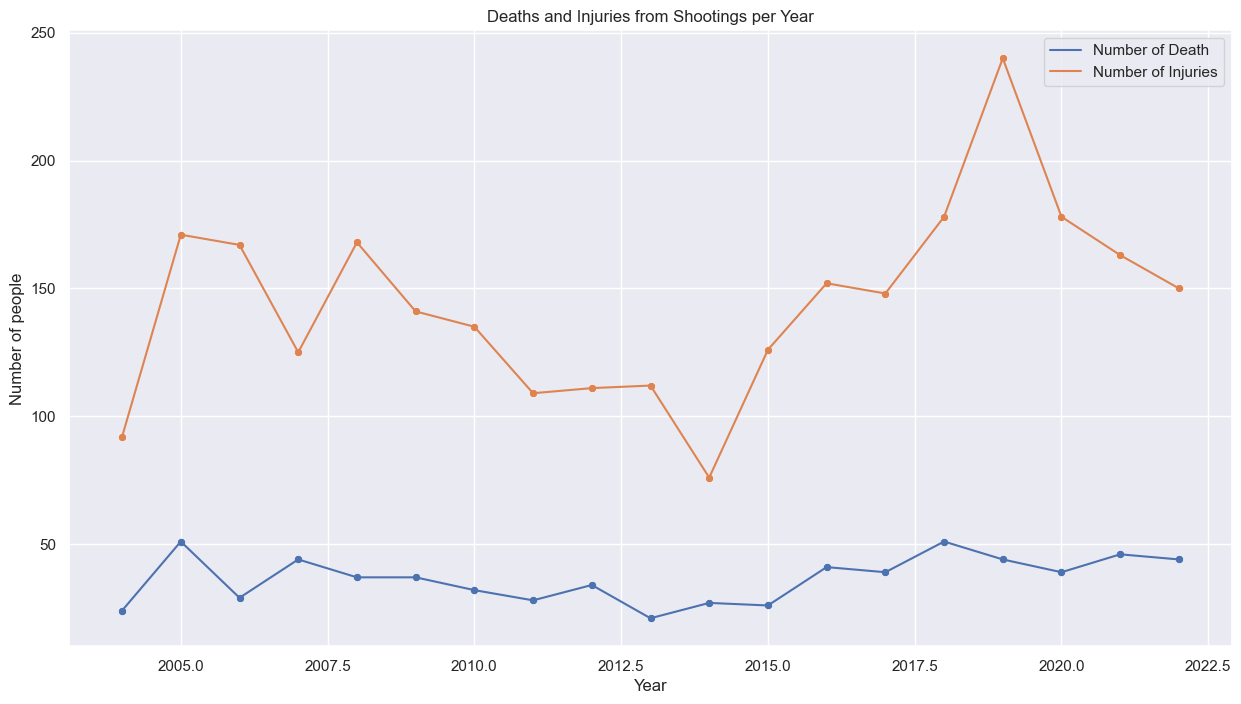

In [225]:
plt.figure(figsize=(15, 8))
sns.lineplot(y='Number_of_Death', x='Year', data=df_death_year, label='Number of Death')
sns.scatterplot(y='Number_of_Death', x='Year', data=df_death_year, marker='o')
sns.lineplot(y='Number_of_Injuries', x='Year', data=df_death_year, label='Number of Injuries')
sns.scatterplot(y='Number_of_Injuries', x='Year', data=df_death_year, marker='o')
plt.title('Deaths and Injuries from Shootings per Year')
plt.xlabel('Year')
plt.ylabel('Number of people')
plt.savefig('deaths_and_injuries.png', bbox_inches='tight')
plt.show()

**What this chart shows:** The total number of people killed and injured in shootings each year. Over 2004–2022 there were 694 deaths and 2,742 injuries.

- **Injuries follow the number of shootings:** they rose with the 2015–2019 increase and peaked at 240 in 2019.
- **Deaths did not rise as much.** They stayed between about 20 and 51 a year, with the highest counts in 2005 and 2018 (51 each).
- The share of incidents that caused a death **fell over time**, from about 0.20 deaths per incident in 2005 and 2007 to about 0.09 in 2019–2020. There were more shootings in recent years, but a smaller share of them were fatal.

Some yearly totals include single large events, for example 24 people injured in one incident in West Hill in July 2012.

## Neighbourhood risk levels

To summarise where shootings are concentrated, we give each neighbourhood a risk level. Two choices make the levels meaningful:

- **Recent data:** we use the last five years (2018-2022), so a neighbourhood that was violent many years ago but is quiet now is not labelled high risk.
- **Data-driven cut-offs:** instead of choosing numbers ourselves, we use percentiles. The top 10% of neighbourhoods by incidents per year are **high** risk, the next 40% are **medium**, and the bottom 50% are **low**.

In [226]:
# Incidents per year in each neighbourhood over 2018-2022 (neighbourhoods with none get 0)
recent=df[df['Year']>=2018]
risk=(recent['Neighbourhood'].value_counts()
        .reindex(df['Neighbourhood'].unique(), fill_value=0)
        .rename_axis('Neighbourhood')
        .reset_index(name='Incidents_2018_2022'))
risk['Incidents_per_year']=risk['Incidents_2018_2022']/5

# Percentile cut-offs: bottom 50% low, next 40% medium, top 10% high
medium_cut=risk['Incidents_per_year'].quantile(0.5)
high_cut=risk['Incidents_per_year'].quantile(0.9)
risk['Risk_level']=pd.cut(risk['Incidents_per_year'],
                          bins=[-np.inf, medium_cut, high_cut, np.inf],
                          labels=['low', 'medium', 'high'])

print('Medium risk: more than', round(medium_cut, 1), 'incidents per year')
print('High risk:   more than', round(high_cut, 1), 'incidents per year')
risk.sort_values('Incidents_per_year', ascending=False).head(10)

Medium risk: more than 1.8 incidents per year
High risk:   more than 6.3 incidents per year


,Neighbourhood,Incidents_2018_2022,Incidents_per_year,Risk_level
40,Glenfield-Jane Heights,119,23.8,high
7,Mount Olive-Silverstone-Jamestown,66,13.2,high
2,Black Creek,62,12.4,high
69,Yorkdale-Glen Park,58,11.6,high
25,York University Heights,53,10.6,high
17,Golfdale-Cedarbrae-Woburn,51,10.2,high
1,West Humber-Clairville,43,8.6,high
36,Oakwood Village,39,7.8,high
57,Flemingdon Park,38,7.6,high
49,Englemount-Lawrence,37,7.4,high


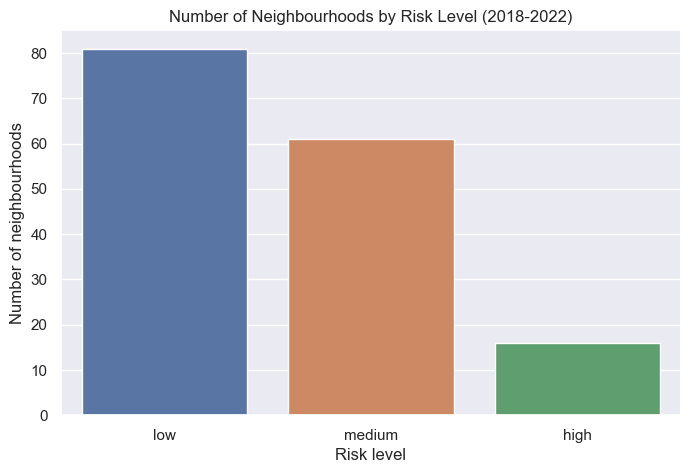

,Risk_level,Neighbourhoods
0,low,81
1,medium,61
2,high,16


In [227]:
# Count neighbourhoods per risk level, in a fixed low -> medium -> high order
df_risk_level=(risk['Risk_level'].value_counts()
                 .reindex(['low', 'medium', 'high'])
                 .rename_axis('Risk_level')
                 .reset_index(name='Neighbourhoods'))

plt.figure(figsize=(8, 5))
sns.barplot(x='Risk_level', y='Neighbourhoods', data=df_risk_level)
plt.title('Number of Neighbourhoods by Risk Level (2018-2022)')
plt.xlabel('Risk level')
plt.ylabel('Number of neighbourhoods')
plt.savefig('risk_levels.png', bbox_inches='tight')
plt.show()
df_risk_level

**What this chart shows:** Neighbourhoods grouped by the number of shooting incidents per year over 2018-2022.

- **16 neighbourhoods are high risk** (more than about 6.3 incidents per year), **61 are medium risk** (more than 1.8 per year) and **81 are low risk**. The groups are not exactly 10%, 40% and 50% because several neighbourhoods have the same number of incidents at the cut-off points.
- **Glenfield-Jane Heights stands out,** with 23.8 incidents per year, almost twice as many as the next neighbourhood (Mount Olive-Silverstone-Jamestown, 13.2).
- **Incidents are concentrated:** the 16 high-risk neighbourhoods (10% of the city) account for 35.3% of all incidents in 2018-2022, while 8 neighbourhoods had no shootings at all in these five years.
- Many high-risk neighbourhoods are in the north-west, but the list also includes parts of Scarborough (such as Golfdale-Cedarbrae-Woburn, West Hill, Eglinton East and Dorset Park) and downtown (Wellington Place).

**Limitation:** These are counts, not rates. A neighbourhood with a large population can have more incidents partly because more people live there.

# Predicting Monthly Shootings by Police Division

**Goal:** predict how many shooting incidents each of Toronto's 17 police divisions will have next month, using only information available before that month starts. A prediction like this could help decide where to send patrol and prevention resources.

**Why police divisions and not neighbourhoods?** A neighbourhood has on average only 0.16 incidents per month, and 87% of neighbourhood-months have none, which gives a model very little to learn from. A division has on average 1.45 incidents per month, which gives a much clearer signal. Divisions are also the units police actually use to plan resources.

**Why monthly and not daily?** Even in the busiest neighbourhood, 96% of days have no shootings, so daily counts are almost all zeros. Monthly totals smooth out this randomness.

**Approach:**
1. Build a table with one row for each division in each month.
2. Create features from each division's past incidents (feature engineering).
3. Split the data by time: train on 2005–2018, test on 2019–2022.
4. Set simple baselines that any useful model must beat.
5. Train a Linear Regression model and a Random Forest model.
6. Compare the models and explain the results.

### Step 1: Build a monthly table of incidents per division

Each row of the cleaned data is one incident. To predict *how many* incidents will happen, we need one row per division per month with the number of incidents as the target. Months with no incidents are included as 0; without them, the model would never learn what a quiet month looks like.

In [228]:
# Count incidents for every division in every month.
# Months with no incidents are included as 0, so the model also learns from quiet months.
all_months = pd.period_range(df['Date'].min(), df['Date'].max(), freq='M')
divisions = sorted(df['Division'].unique())
full_index = pd.MultiIndex.from_product([divisions, all_months], names=['Division', 'Month_Period'])

monthly = (df.groupby(['Division', df['Date'].dt.to_period('M').rename('Month_Period')])
             .size()
             .reindex(full_index, fill_value=0)
             .rename('Incidents')
             .reset_index())

print('Rows:', len(monthly), '|', len(divisions), 'divisions x', len(all_months), 'months')
print('Average incidents per division per month:', round(monthly['Incidents'].mean(), 2))
print('Share of division-months with zero incidents:', round((monthly['Incidents'] == 0).mean() * 100, 1), '%')
monthly.head()

Rows: 3876 | 17 divisions x 228 months
Average incidents per division per month: 1.45
Share of division-months with zero incidents: 36.4 %


,Division,Month_Period,Incidents
0,D11,2004-01,0
1,D11,2004-02,0
2,D11,2004-03,0
3,D11,2004-04,0
4,D11,2004-05,0


The table has 3,876 rows (17 divisions × 228 months, January 2004 to December 2022). A division has on average 1.45 incidents per month, and 36% of division-months have no incidents at all.

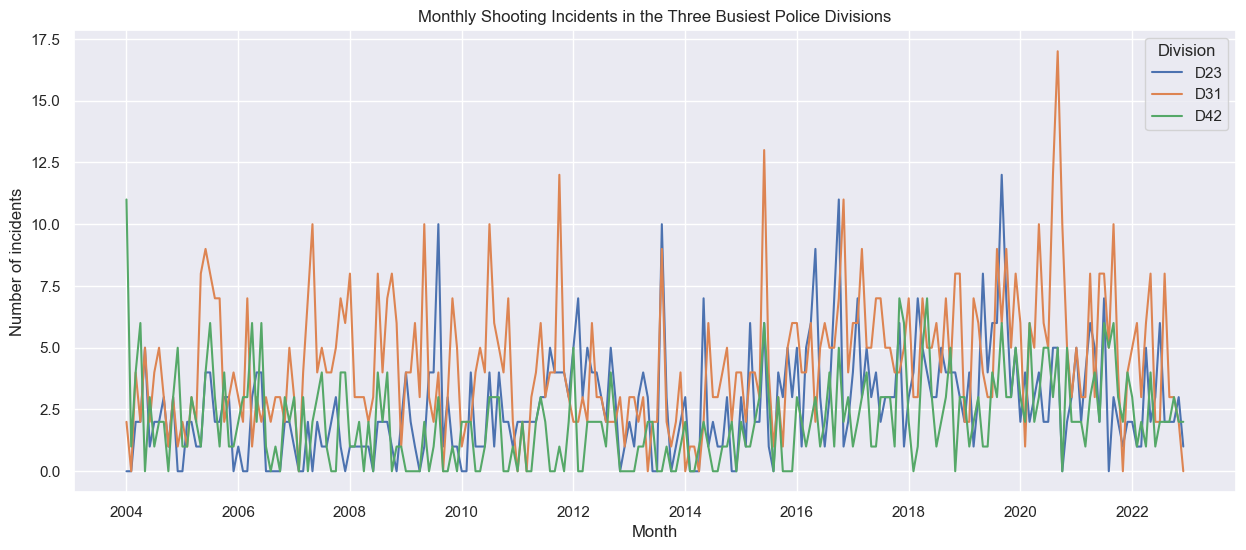

In [229]:
# Monthly incidents for the three divisions with the most shootings
top_divisions = monthly.groupby('Division')['Incidents'].sum().nlargest(3).index
plot_data = monthly[monthly['Division'].isin(top_divisions)].copy()
plot_data['Month'] = plot_data['Month_Period'].dt.to_timestamp()

plt.figure(figsize=(15, 6))
sns.lineplot(x='Month', y='Incidents', hue='Division', data=plot_data)
plt.title('Monthly Shooting Incidents in the Three Busiest Police Divisions')
plt.xlabel('Month')
plt.ylabel('Number of incidents')
plt.savefig('division_monthly_incidents.png', bbox_inches='tight')
plt.show()

**What this chart shows:** Division 31 has the most incidents almost every month (4.35 per month on average over 2004–2022). All three divisions show the citywide increase after 2015.

The monthly numbers jump up and down a lot. For example, Division 31 had 17 incidents in September 2020, several times its normal level. Sudden spikes like this are very hard for any model to predict, so we should expect a model to capture the general **level** of each division rather than every individual month.

### Step 2: Feature engineering

Each feature describes what happened **before** the month we are predicting. This is the most important rule: if a feature used information from the month itself (for example, that month's deaths or injuries), the model would be "cheating" and would fail on real future data. This problem is called **data leakage**.

| Feature | Meaning |
|---|---|
| `Lag_1`, `Lag_2` | Incidents in the division 1 and 2 months earlier |
| `Lag_12` | Incidents in the same month one year earlier |
| `Rolling_3`, `Rolling_12` | Average monthly incidents over the previous 3 and 12 months |
| `Division_History` | The division's average monthly incidents over all previous months |
| `City_Lag_1`, `City_Rolling_12` | Total citywide incidents last month and the 12-month citywide average. These capture citywide waves, such as the 2015–2019 increase. |
| `Month_Sin`, `Month_Cos` | Month of the year, encoded on a circle so that December and January are next to each other |
| `Year` | The long-term trend |

The first 12 months of each division are dropped because they don't have a full year of history for `Lag_12` and `Rolling_12`.

In [230]:
def add_features(monthly):
    """Create features for each division-month using only information from earlier months."""
    data = monthly.sort_values(['Division', 'Month_Period']).copy()
    by_division = data.groupby('Division')['Incidents']

    # Recent history of the same division
    data['Lag_1'] = by_division.shift(1)     # incidents last month
    data['Lag_2'] = by_division.shift(2)     # incidents two months ago
    data['Lag_12'] = by_division.shift(12)   # incidents in the same month last year
    data['Rolling_3'] = by_division.transform(lambda s: s.shift(1).rolling(3).mean())
    data['Rolling_12'] = by_division.transform(lambda s: s.shift(1).rolling(12).mean())
    data['Division_History'] = by_division.transform(lambda s: s.shift(1).expanding().mean())

    # Citywide activity (captures waves that affect all divisions at once)
    city = data.groupby('Month_Period')['Incidents'].sum()
    data['City_Lag_1'] = data['Month_Period'].map(city.shift(1))
    data['City_Rolling_12'] = data['Month_Period'].map(city.shift(1).rolling(12).mean())

    # Calendar: month of year as a circle, so December and January are neighbours
    month = data['Month_Period'].dt.month
    data['Month_Sin'] = np.sin(2 * np.pi * month / 12)
    data['Month_Cos'] = np.cos(2 * np.pi * month / 12)
    data['Year'] = data['Month_Period'].dt.year

    # The first 12 months of each division have no full history, so drop them
    return data.dropna().reset_index(drop=True)


model_data = add_features(monthly)
feature_cols = ['Lag_1', 'Lag_2', 'Lag_12', 'Rolling_3', 'Rolling_12', 'Division_History',
                'City_Lag_1', 'City_Rolling_12', 'Month_Sin', 'Month_Cos', 'Year']
print('Rows after removing the first 12 months:', len(model_data))
model_data[['Division', 'Month_Period', 'Incidents'] + feature_cols].head()

Rows after removing the first 12 months: 3672


,Division,Month_Period,Incidents,Lag_1,Lag_2,Lag_12,Rolling_3,Rolling_12,Division_History,City_Lag_1,City_Rolling_12,Month_Sin,Month_Cos,Year
0,D11,2005-01,0,1.0,0.0,0.0,0.333333,0.166667,0.166667,14.0,15.166667,0.500000,8.660254e-01,2005
1,D11,2005-02,0,0.0,1.0,0.0,0.333333,0.166667,0.153846,15.0,14.750000,0.866025,5.000000e-01,2005
2,D11,2005-03,0,0.0,0.0,0.0,0.333333,0.166667,0.142857,16.0,15.750000,1.000000,6.123234e-17,2005
3,D11,2005-04,1,0.0,0.0,0.0,0.000000,0.166667,0.133333,19.0,15.916667,0.866025,-5.000000e-01,2005
4,D11,2005-05,0,1.0,0.0,0.0,0.333333,0.250000,0.187500,18.0,16.000000,0.500000,-8.660254e-01,2005


### Step 3: Split the data by time

With time-based data, a random train/test split would mix future months into the training data, and the test results would look better than they really are. Instead we train on the past and test on the future:

- **Training set:** 2005–2018 (2,856 rows)
- **Test set:** 2019–2022 (816 rows)

The test period is harder than the training period: divisions averaged about 2.1 incidents per month in 2019–2022 compared with about 1.3 in 2005–2018.

In [231]:
# Time-based split: learn from the past, test on the future
train = model_data[model_data['Year'] <= 2018].sort_values(['Month_Period', 'Division'])
test = model_data[model_data['Year'] >= 2019].sort_values(['Month_Period', 'Division'])

X_train, y_train = train[feature_cols], train['Incidents']
X_test, y_test = test[feature_cols], test['Incidents']

print('Training set:', train['Month_Period'].min(), 'to', train['Month_Period'].max(), '-', len(train), 'rows')
print('Test set:    ', test['Month_Period'].min(), 'to', test['Month_Period'].max(), '-', len(test), 'rows')

Training set: 2005-01 to 2018-12 - 2856 rows
Test set:     2019-01 to 2022-12 - 816 rows


### Step 4: Baselines

A baseline is a very simple prediction rule. A machine learning model is only useful if it does better than the baseline. We use two:

1. **Same as last month:** predict that next month will have the same number of incidents as this month.
2. **Average of the last 12 months:** predict the division's average monthly incidents over the past year.

We measure errors with two metrics:
- **MAE (mean absolute error):** on average, how many incidents the prediction is off by. This is our main measure because it is easy to explain.
- **RMSE (root mean squared error):** similar, but it gives more weight to large mistakes.

In [232]:
def evaluate(name, y_true, y_pred):
    """Return the error measures for one set of predictions."""
    return {'Model': name,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))}

results = [
    evaluate('Baseline: same as last month', y_test, test['Lag_1']),
    evaluate('Baseline: average of last 12 months', y_test, test['Rolling_12']),
]
pd.DataFrame(results).round(3)

,Model,MAE,RMSE
0,Baseline: same as last month,1.605,2.245
1,Baseline: average of last 12 months,1.341,1.786


**Result:** Predicting "same as last month" is off by 1.605 incidents per division-month on average (MAE). The 12-month average is much better, with an MAE of 1.341, because one month is too noisy to be a good guide. **The models below need to beat an MAE of 1.341.**

### Step 5: Linear Regression

Linear Regression predicts the number of incidents as a weighted sum of the features. It is simple and easy to interpret, so it is a good first model.

In [233]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test).clip(min=0)   # a count cannot be negative

results.append(evaluate('Linear Regression', y_test, linear_pred))
pd.DataFrame(results).round(3)

,Model,MAE,RMSE
0,Baseline: same as last month,1.605,2.245
1,Baseline: average of last 12 months,1.341,1.786
2,Linear Regression,1.315,1.723


**Result:** Linear Regression has an MAE of 1.315 and an RMSE of 1.723. It beats both baselines, but only slightly. The model relies mostly on `Division_History` (coefficient 0.54) and `Rolling_12` (0.44). In other words, it predicts a mix of the division's long-run average and its average over the past year, with a small increase for summer months.

### Step 6: Random Forest

A Random Forest combines hundreds of decision trees, each trained on a different random sample of the data, and averages their predictions. Unlike Linear Regression, it can learn non-linear patterns. For example, it can learn that a busy division stays busy after a quiet month.

A Random Forest has settings (hyperparameters) that control how complex each tree can be. We choose them with **cross-validation**. Because the data is ordered in time, we use `TimeSeriesSplit`: each fold trains on earlier months and validates on the months that follow. Only the training data (2005–2018) is used for this, so the test set stays unseen until the final evaluation.

In [234]:
# Tune the Random Forest with time-series cross-validation on the training data only.
# Each fold trains on earlier months and validates on the months that follow.
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'max_depth': [5, 10, None],
    'min_samples_leaf': [5, 20, 50],
}
grid_search = GridSearchCV(
    RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
)
grid_search.fit(X_train, y_train)

print('Best settings:', grid_search.best_params_)
print('Cross-validation MAE:', round(-grid_search.best_score_, 3))

Best settings: {'max_depth': 5, 'min_samples_leaf': 20}
Cross-validation MAE: 0.969


**Result:** The best settings are `max_depth=5` and `min_samples_leaf=20`, which means small, simple trees. Deeper trees memorise noise in the training data and predict worse, which confirms how random the monthly counts are.

The cross-validation MAE (0.97) is lower than the test MAE below. This is expected: the training years had fewer incidents than 2019–2022, so their errors are smaller.

In [235]:
rf_model = grid_search.best_estimator_
rf_pred = rf_model.predict(X_test)

results.append(evaluate('Random Forest', y_test, rf_pred))
results_table = pd.DataFrame(results).round(3)
results_table

,Model,MAE,RMSE
0,Baseline: same as last month,1.605,2.245
1,Baseline: average of last 12 months,1.341,1.786
2,Linear Regression,1.315,1.723
3,Random Forest,1.298,1.738


**Result:** The Random Forest has the lowest MAE (1.298). That is 3.2% better than the 12-month average baseline and 19% better than the "same as last month" baseline. Linear Regression has a slightly lower RMSE (1.723 vs 1.738), so it makes slightly fewer large mistakes. Overall, the two models perform almost the same.

We choose the **Random Forest as the final model** because it has the lowest average error (MAE), our main measure.

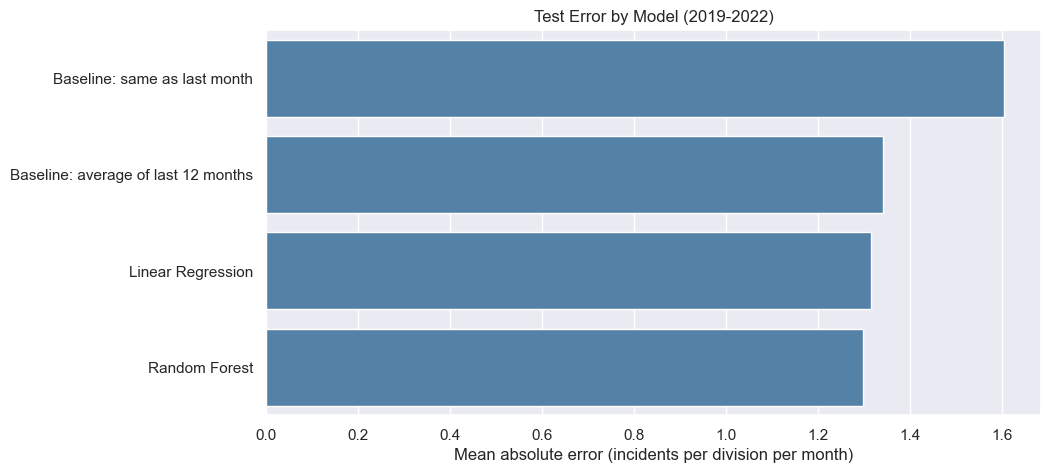

In [236]:
plt.figure(figsize=(10, 5))
sns.barplot(x='MAE', y='Model', data=results_table, color='steelblue')
plt.title('Test Error by Model (2019-2022)')
plt.xlabel('Mean absolute error (incidents per division per month)')
plt.ylabel('')
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

**What this chart shows:** Both models beat the two baselines, and the Random Forest has the smallest average error. However, the gap between the best model and the 12-month average is small. Most of what can be predicted comes from a division's recent level of activity.

### Step 7: What does the model rely on?

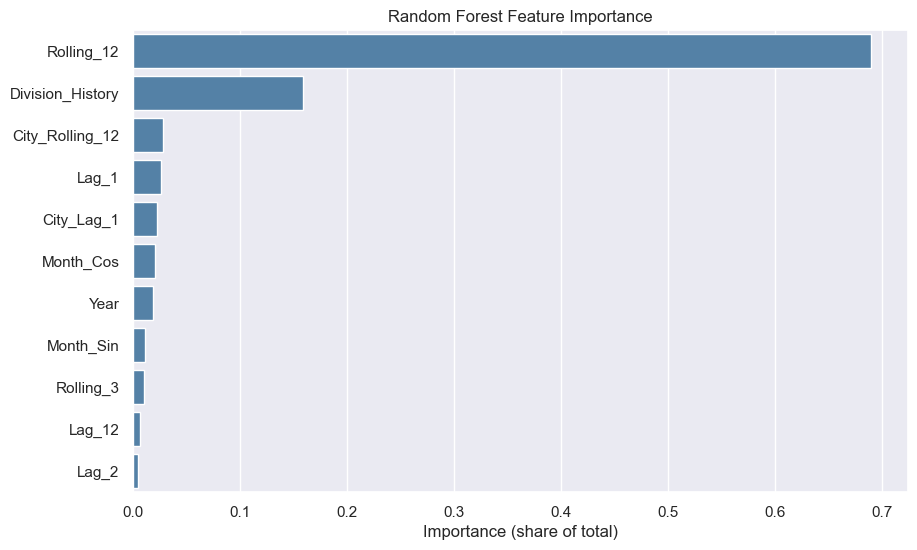

Rolling_12          0.690
Division_History    0.159
City_Rolling_12     0.028
Lag_1               0.026
City_Lag_1          0.023
Month_Cos           0.021
Year                0.019
Month_Sin           0.011
Rolling_3           0.010
Lag_12              0.007
Lag_2               0.005
dtype: float64

In [237]:
importance = (pd.Series(rf_model.feature_importances_, index=feature_cols)
                .sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, color='steelblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (share of total)')
plt.ylabel('')
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
importance.round(3)

**What this chart shows:** The model relies almost entirely on two features: the average over the last 12 months (`Rolling_12`, 69%) and the division's long-run history (`Division_History`, 16%). Together they account for 85% of the model's decisions.

Last month's count, the month of the year and the citywide features add very little. The best guide to next month is a division's **recent typical level**, not what happened last month. This matches the finding that month-to-month changes are mostly random.

### Step 8: Actual vs predicted incidents in the test period

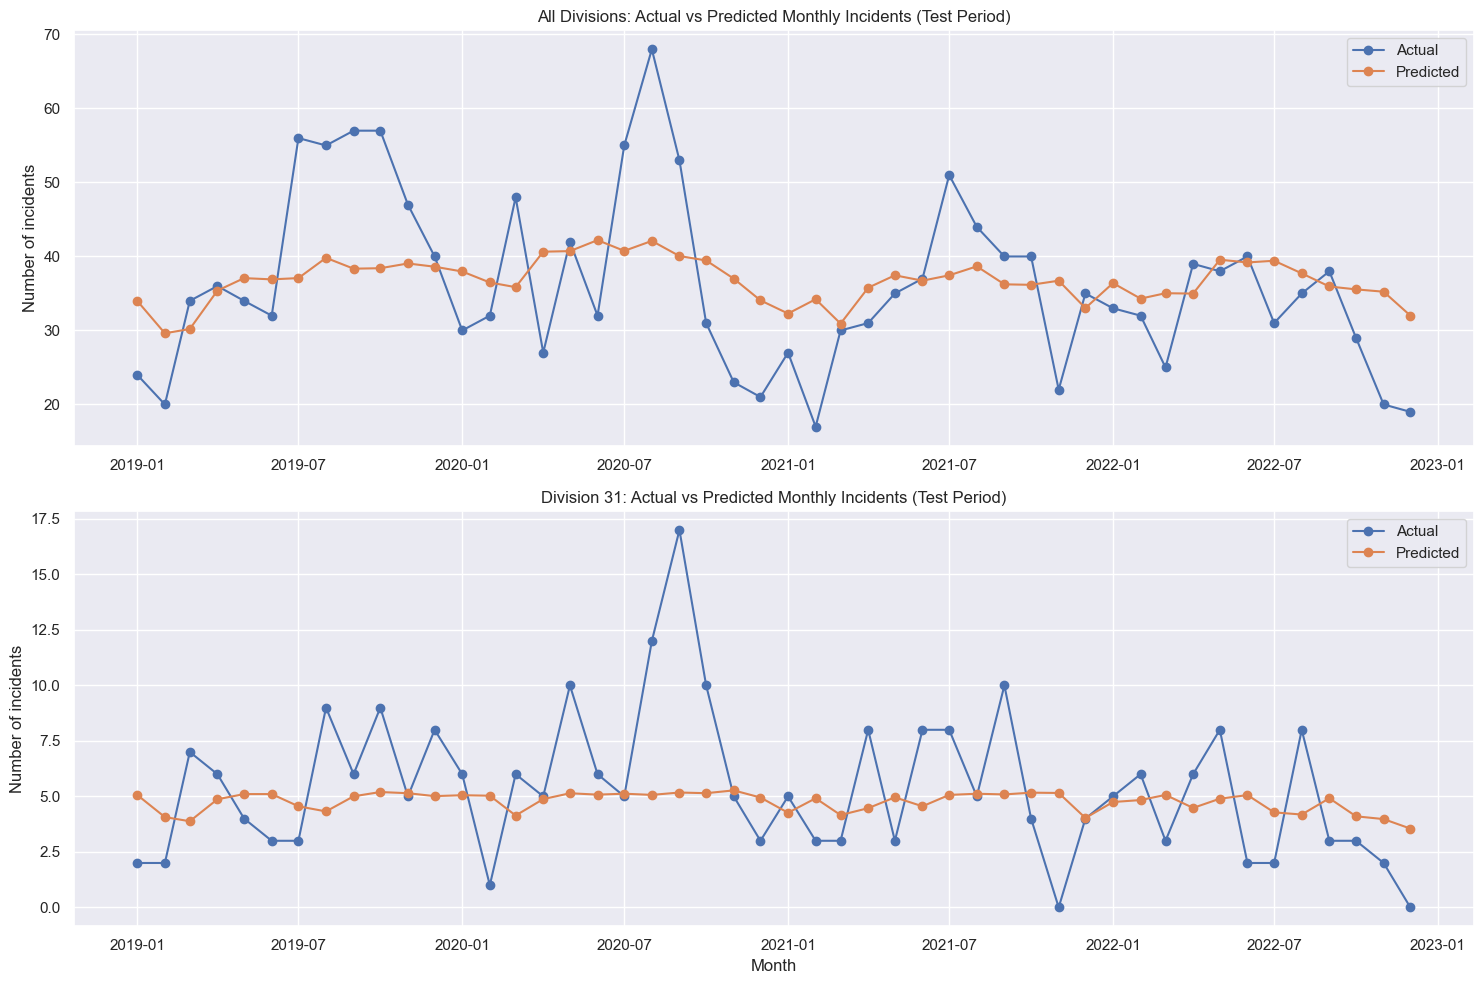

In [238]:
test_results = test[['Division', 'Month_Period', 'Incidents']].copy()
test_results['Predicted'] = rf_pred
test_results['Month'] = test_results['Month_Period'].dt.to_timestamp()

# Citywide: add up all divisions for each month
city_results = test_results.groupby('Month')[['Incidents', 'Predicted']].sum()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
axes[0].plot(city_results.index, city_results['Incidents'], marker='o', label='Actual')
axes[0].plot(city_results.index, city_results['Predicted'], marker='o', label='Predicted')
axes[0].set_title('All Divisions: Actual vs Predicted Monthly Incidents (Test Period)')
axes[0].set_ylabel('Number of incidents')
axes[0].legend()

d31 = test_results[test_results['Division'] == 'D31']
axes[1].plot(d31['Month'], d31['Incidents'], marker='o', label='Actual')
axes[1].plot(d31['Month'], d31['Predicted'], marker='o', label='Predicted')
axes[1].set_title('Division 31: Actual vs Predicted Monthly Incidents (Test Period)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of incidents')
axes[1].legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

**What these charts show:**

- **All divisions (top chart):** On average the model gets the level right: 36.7 predicted incidents per month compared with 36.3 actual. But the predictions are much smoother than reality. They stay between about 30 and 42, while actual monthly totals ranged from 17 (February 2021) to 68 (August 2020).
- **Missed spikes:** The model did not predict the high summer months of 2019 (55–57 incidents a month from July to October) or August 2020.
- **Slow to react:** Because it relies on the 12-month average, the model adjusts slowly to changes in the trend. It under-predicted 2019 (434 predicted vs 492 actual) and over-predicted 2022 (435 predicted vs 379 actual), when shootings were falling.
- **Division 31 (bottom chart):** The model predicts between about 3.5 and 5.3 incidents every month, while actual counts ranged from 0 to 17. It captures the division's typical level but not the individual peaks.

In [239]:
# Test error for each division, next to how busy the division is
division_errors = (test_results.assign(Abs_Error=(test_results['Incidents'] - test_results['Predicted']).abs())
                     .groupby('Division')
                     .agg(Average_Monthly_Incidents=('Incidents', 'mean'), MAE=('Abs_Error', 'mean'))
                     .sort_values('Average_Monthly_Incidents', ascending=False)
                     .round(2))
division_errors

,Average_Monthly_Incidents,MAE
Division,,
D31,5.40,2.46
D43,3.62,1.78
D23,3.42,1.76
D42,2.94,1.28
D12,2.77,1.71
D32,2.65,1.58
D41,2.12,1.47
D54,1.71,1.26
D51,1.71,1.11


**What this table shows:** The busiest divisions have the largest errors in absolute terms. Division 31 is off by 2.46 incidents per month, but it also averages 5.40 incidents per month. Relative to their activity, busy divisions are predicted **more** accurately than quiet ones. For example, Division 52 averages 0.69 incidents per month but has an MAE of 0.91, because in a quiet division a single unexpected shooting is a large error.

### Conclusion

- We predicted monthly shooting incidents for each of Toronto's 17 police divisions using only past information, and tested the models on 2019–2022, data the models had never seen.
- The **Random Forest** was the best model, with an average error of **1.30 incidents per division per month**. That is better than both baselines, but only 3.2% better than simply using the last 12-month average.
- The most useful information is a division's **recent typical level**. The model is good at identifying which divisions will be busy, but it cannot predict sudden spikes or quickly detect a change in the trend.

**Limitations:**
- Shootings are rare and partly random events, so month-to-month changes are hard to predict from past counts alone.
- The model only uses past incident counts. It has no information about the causes of violence, such as population, economic conditions, policing changes or major events.
- The test period includes the COVID-19 pandemic (2020–2021), which may have changed normal patterns.

**Possible improvements:**
- Add external data, such as population per division (to compute rates), weather, holidays and school terms.
- Try models designed for count data, such as Poisson regression.
- Predict per quarter instead of per month, which would reduce the randomness further.